<a href="https://colab.research.google.com/github/SamInMotion/customer-churn-explainable-prediction/blob/main/Churn_Predictive_modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION

This notebook builds an explainable machine learning model to predict customer churn based on historical service data. We focus on model interpretability and business relevance.

# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

We begin by importing the required Python libraries for data manipulation, visualization, and modeling.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

The dataset contains customer attributes and a binary target variable (churn). We load and inspect its shape and a few rows.

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [9]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm.

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging.

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [7]:
model = RandomForestClassifier(
    n_estimators=100, # Number of trees in the forest
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

How likely the model is to assign higher or lower probabilities.

In [11]:
# If you want to generate predictions on the test set again:
test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)[:, 1]  # Probability of churn

accuracy = accuracy_score(y_test, test_predictions)
roc_auc = roc_auc_score(y_test, test_probabilities)
precision = precision_score(y_test, test_predictions)
recall = recall_score(y_test, test_predictions)
f1 = f1_score(y_test, test_predictions)

print("\n=== Evaluation (Default Threshold = 0.5) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


=== Evaluation (Default Threshold = 0.5) ===
Accuracy : 0.9042
ROC AUC  : 0.6548
Precision: 0.8333
Recall   : 0.0546
F1 Score : 0.1026


We evaluate performance using accuracy, precision, recall, and a confusion matrix.
While accuracy is high, recall is relatively low, meaning the model is cautious in flagging churners — which aligns with our precision-focused business case.


Confusion Matrix (Default Threshold):
[[3282    4]
 [ 346   20]]


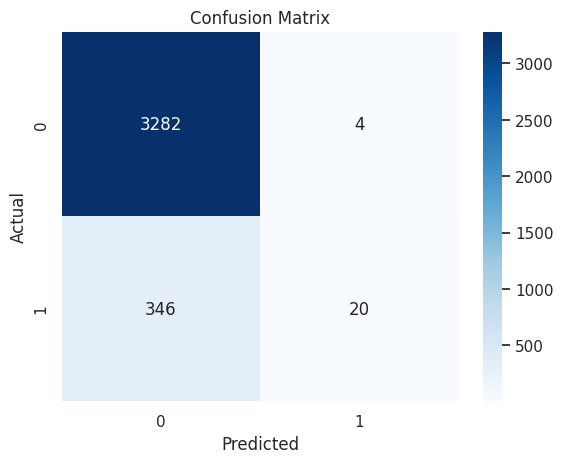

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_predictions)
print("\nConfusion Matrix (Default Threshold):")
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Evaluate and experimenting with custom thresholds (0.1, 0.2, 0.3, 0.4)

In [13]:
print("\nMin prob:", test_probabilities.min())
print("Max prob:", test_probabilities.max())
print("Mean prob:", test_probabilities.mean())

print("\n=== Evaluation with Custom Thresholds ===")
for threshold in [0.1, 0.2, 0.3, 0.4]:
    preds_thresh = (test_probabilities >= threshold).astype(int)
    precision_t = precision_score(y_test, preds_thresh)
    recall_t = recall_score(y_test, preds_thresh)
    f1_t = f1_score(y_test, preds_thresh)
    print(
        f"Threshold: {threshold}, "
        f"Precision: {precision_t:.3f}, "
        f"Recall: {recall_t:.3f}, "
        f"F1: {f1_t:.3f}"
    )



Min prob: 0.0
Max prob: 0.98
Mean prob: 0.09526013143483024

=== Evaluation with Custom Thresholds ===
Threshold: 0.1, Precision: 0.152, Recall: 0.574, F1: 0.241
Threshold: 0.2, Precision: 0.273, Recall: 0.298, F1: 0.285
Threshold: 0.3, Precision: 0.427, Recall: 0.145, F1: 0.216
Threshold: 0.4, Precision: 0.615, Recall: 0.087, F1: 0.153


We observe that customers with short contracts or high energy consumption are more likely to churn.

 Implementing Uncertainty Visualization

 We use bootstrap resampling to estimate the confidence interval of the model's accuracy.

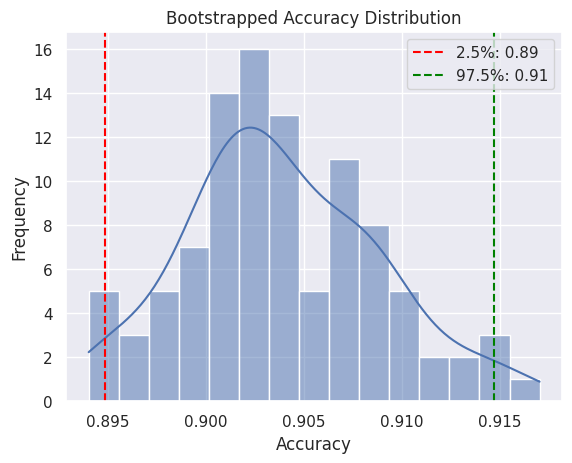

In [15]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

bootstrapped_accuracies = []
n_iterations = 100

for i in range(n_iterations):
    X_resampled, y_resampled = resample(X_test, y_test, random_state=i)
    y_pred = model.predict(X_resampled)
    acc = accuracy_score(y_resampled, y_pred)
    bootstrapped_accuracies.append(acc)

# Confidence Interval
ci_lower = np.percentile(bootstrapped_accuracies, 2.5)
ci_upper = np.percentile(bootstrapped_accuracies, 97.5)

# Plot
sns.histplot(bootstrapped_accuracies, bins=15, kde=True)
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5%: {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', label=f'97.5%: {ci_upper:.2f}')
plt.title('Bootstrapped Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.show()


2. Implementing Explainable AI (SHAP)

We use SHAP to understand feature importance and explain individual predictions. This helps business users trust and interpret the model output.

In [17]:
pip install shap


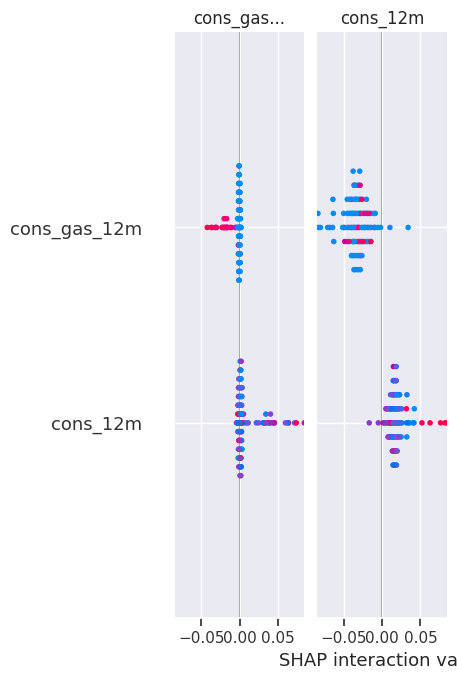

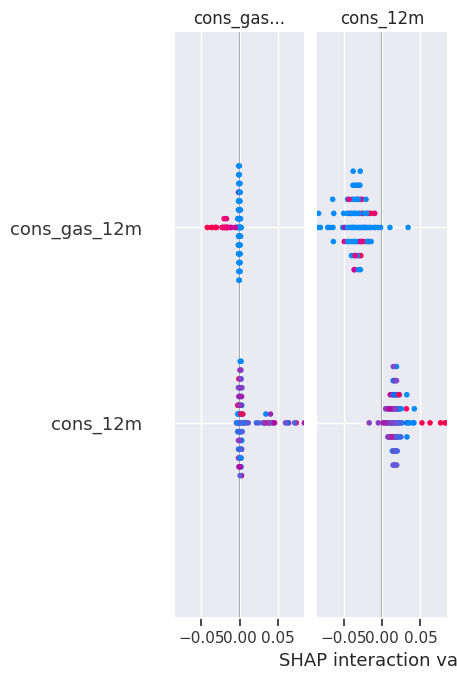

In [19]:
import shap
import pandas as pd
import numpy as np

# Ensure X_test is numeric
X_test_numeric = X_test.select_dtypes(include=[np.number])

# Sample a few rows to reduce computation time
X_sample = X_test_numeric.sample(100, random_state=42)

# TreeExplainer for RandomForest
explainer = shap.TreeExplainer(model)

# Get SHAP values
shap_values = explainer.shap_values(X_sample)

# Plot summary (bar for feature importance, dot for distribution)
shap.summary_plot(shap_values, X_sample, plot_type="bar")
shap.summary_plot(shap_values, X_sample)



Customers with high gas consumption over the past 12 months are more likely to churn. This effect is stronger when combined with high total consumption (cons_12m), suggesting that heavy energy users — especially those dependent on gas — may be at higher risk. This insight could inform targeted pricing or retention strategies for high-usage households.